**0. SET UP ENVIRONMENT**

In [3]:
!pip install duckdb

In [4]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**0.1 DATA UNDERSTANDING**

In [ ]:
# Review data table
orders = con.execute("""
select *
from read_csv_auto('/content/drive/MyDrive/Data Project - Brazillian/olist_orders_dataset.csv')
""").df()

orders.head()

SyntaxError: invalid syntax (862253248.py, line 1)

In [ ]:
# Check table schema
con.execute("""
describe select *
from read_csv_auto('/content/drive/MyDrive/Data Project - Brazillian/olist_orders_dataset.csv')
""").df()

,column_name,column_type,null,key,default,extra
0,order_id,VARCHAR,YES,None,None,None
1,customer_id,VARCHAR,YES,None,None,None
2,order_status,VARCHAR,YES,None,None,None
3,order_purchase_timestamp,TIMESTAMP,YES,None,None,None
4,order_approved_at,TIMESTAMP,YES,None,None,None
5,order_delivered_carrier_date,TIMESTAMP,YES,None,None,None
6,order_delivered_customer_date,TIMESTAMP,YES,None,None,None
7,order_estimated_delivery_date,TIMESTAMP,YES,None,None,None


In [ ]:
# Check order status distribution
con.execute("""
select order_status, COUNT(*)
from read_csv_auto('/content/drive/MyDrive/Data Project - Brazillian/olist_orders_dataset.csv')
GROUP BY order_status
""").df()

,order_status,count_star()
0,delivered,96478
1,invoiced,314
2,shipped,1107
3,processing,301
4,unavailable,609
5,canceled,625
6,created,5
7,approved,2


**1. Cohort Analysis**

In [ ]:
# Create table for data analysis
con.execute("""
create or replace table orders_clean as
  with a as (
    select
      o.order_id,
      c.customer_unique_id,
      o.order_purchase_timestamp,
      o.order_status,
      p.payment_value as revenue
    from read_csv_auto('/content/drive/MyDrive/Data Project - Brazillian/olist_orders_dataset.csv') o
      left join read_csv_auto('/content/drive/MyDrive/Data Project - Brazillian/olist_customers_dataset.csv') c
on o.customer_id = c.customer_id
      left join read_csv_auto('/content/drive/MyDrive/Data Project - Brazillian/olist_order_payments_dataset.csv') p
              on o.order_id = p.order_id
    where o.order_status = 'delivered'
    )
    select
      a.order_id,
      a.customer_unique_id,
      cast(a.order_purchase_timestamp as timestamp) as purchase_ts,
      revenue
    from a

  """
  )
;
con.execute("""
select * from orders_clean
""").df()

,order_id,customer_unique_id,purchase_ts,revenue
0,0b339dee90210409b715a9f2b6af29a7,e6aede5b2818df1b512845c729cf7463,2017-11-29 13:49:23,1166.43
1,2149fe82b3e2d55f500ffe8406412733,b168e38b8070518dc32151b68c996fd6,2018-04-28 00:21:17,119.40
2,b9224c19c5ea3ae062a0141931846476,7bb854844864db3e6321acdc15e1066b,2017-06-20 14:21:18,44.38
3,f6586a410980be02b8a408eb2d0a5c21,bc68dfa77e201dc856450d8d919e8343,2017-05-16 22:42:57,297.42
4,3ce8c5cf3d6b4356d90656b6ac73ab9a,0c85013ac2f907200089cd3461382a06,2017-07-10 21:37:19,46.85
...,...,...,...,...
100752,b0f913cb83681e8a8563b96b641b3e1b,2f8b722d3e62bb8a9860c7a29ad2b60f,2017-01-28 17:59:37,6.82
100753,b0f913cb83681e8a8563b96b641b3e1b,2f8b722d3e62bb8a9860c7a29ad2b60f,2017-01-28 17:59:37,9.05
100754,b0f913cb83681e8a8563b96b641b3e1b,2f8b722d3e62bb8a9860c7a29ad2b60f,2017-01-28 17:59:37,8.35
100755,b0f913cb83681e8a8563b96b641b3e1b,2f8b722d3e62bb8a9860c7a29ad2b60f,2017-01-28 17:59:37,32.00


In [ ]:
# First purchase of each customer
con.execute("""
  create or replace table customer_first_purchase as
  select
      customer_unique_id,
      min(purchase_ts) as first_purchase_ts
  from orders_clean
  group by customer_unique_id
""")
;
con.execute("""
  select * from customer_first_purchase
  order by 2
""").df()

,customer_unique_id,first_purchase_ts
0,830d5b7aaa3b6f1e9ad63703bec97d23,2016-09-15 12:16:38
1,32ea3bdedab835c3aa6cb68ce66565ef,2016-10-03 09:44:50
2,2f64e403852e6893ae37485d5fcacdaf,2016-10-03 16:56:50
3,61db744d2f835035a5625b59350c6b63,2016-10-03 21:13:36
4,8d3a54507421dbd2ce0a1d58046826e0,2016-10-03 22:06:03
...,...,...
93353,7a22d14aa3c3599238509ddca4b93b01,2018-08-29 12:25:59
93354,5c58de6fb80e93396e2f35642666b693,2018-08-29 14:18:23
93355,7febafa06d9d8f232a900a2937f04338,2018-08-29 14:18:28
93356,b701bebbdf478f5500348f03aff62121,2018-08-29 14:52:00


In [ ]:
# Cohort base
con.execute("""
create or replace table cohort_base as
with
  cohort_table as (
    select
        customer_unique_id,
        first_purchase_ts,
        date_trunc('month', first_purchase_ts) as cohort_month
    from customer_first_purchase
  )
  select
    o.customer_unique_id,
    o.purchase_ts,
    c.first_purchase_ts,
    c.cohort_month,
    date_diff('month', c.first_purchase_ts, o.purchase_ts) as month_number,
    o.revenue
  from orders_clean o join cohort_table c
       on o.customer_unique_id = c.customer_unique_id
""")


In [ ]:
 con.execute("""
  select *   from cohort_base limit 10
  """).df()

,customer_unique_id,purchase_ts,first_purchase_ts,cohort_month,month_number,revenue
0,e6aede5b2818df1b512845c729cf7463,2017-11-29 13:49:23,2017-11-29 13:49:23,2017-11-01,0,1166.43
1,b168e38b8070518dc32151b68c996fd6,2018-04-28 00:21:17,2018-04-28 00:21:17,2018-04-01,0,119.40
2,7bb854844864db3e6321acdc15e1066b,2017-06-20 14:21:18,2017-06-20 14:21:18,2017-06-01,0,44.38
3,bc68dfa77e201dc856450d8d919e8343,2017-05-16 22:42:57,2017-05-16 22:42:57,2017-05-01,0,297.42
4,0c85013ac2f907200089cd3461382a06,2017-07-10 21:37:19,2017-07-10 21:37:19,2017-07-01,0,46.85
5,9b22d6fe1f74d6e1aefec789415ec847,2017-07-24 02:41:57,2017-07-24 02:41:57,2017-07-01,0,77.52
6,f86c68d3fd5ce93aa8b7e7d6e205f575,2018-06-28 12:47:48,2018-06-28 12:47:48,2018-06-01,0,79.80
7,71c5fcbc06a5696db6d5f3aaf0499bb4,2017-10-23 17:07:40,2017-10-23 17:07:40,2017-10-01,0,158.40
8,925ec947e25969a9f589ed25c3d9ffce,2018-02-21 22:38:45,2018-02-21 22:38:45,2018-02-01,0,166.50
9,75c23d066292aeca5ccb1db8ff8bf883,2018-03-29 16:00:06,2018-03-29 16:00:06,2018-03-01,0,162.14


In [ ]:
# Active user
retention  = con.execute("""
  select
      cohort_month,
      month_number,
      count(distinct customer_unique_id) as active_users
  from cohort_base
  group by 1,2
  order by 1,2
"""
).df()
;
retention.head()

,cohort_month,month_number,active_users
0,2016-09-01,0,1
1,2016-10-01,0,262
2,2016-10-01,6,1
3,2016-10-01,9,1
4,2016-10-01,11,1


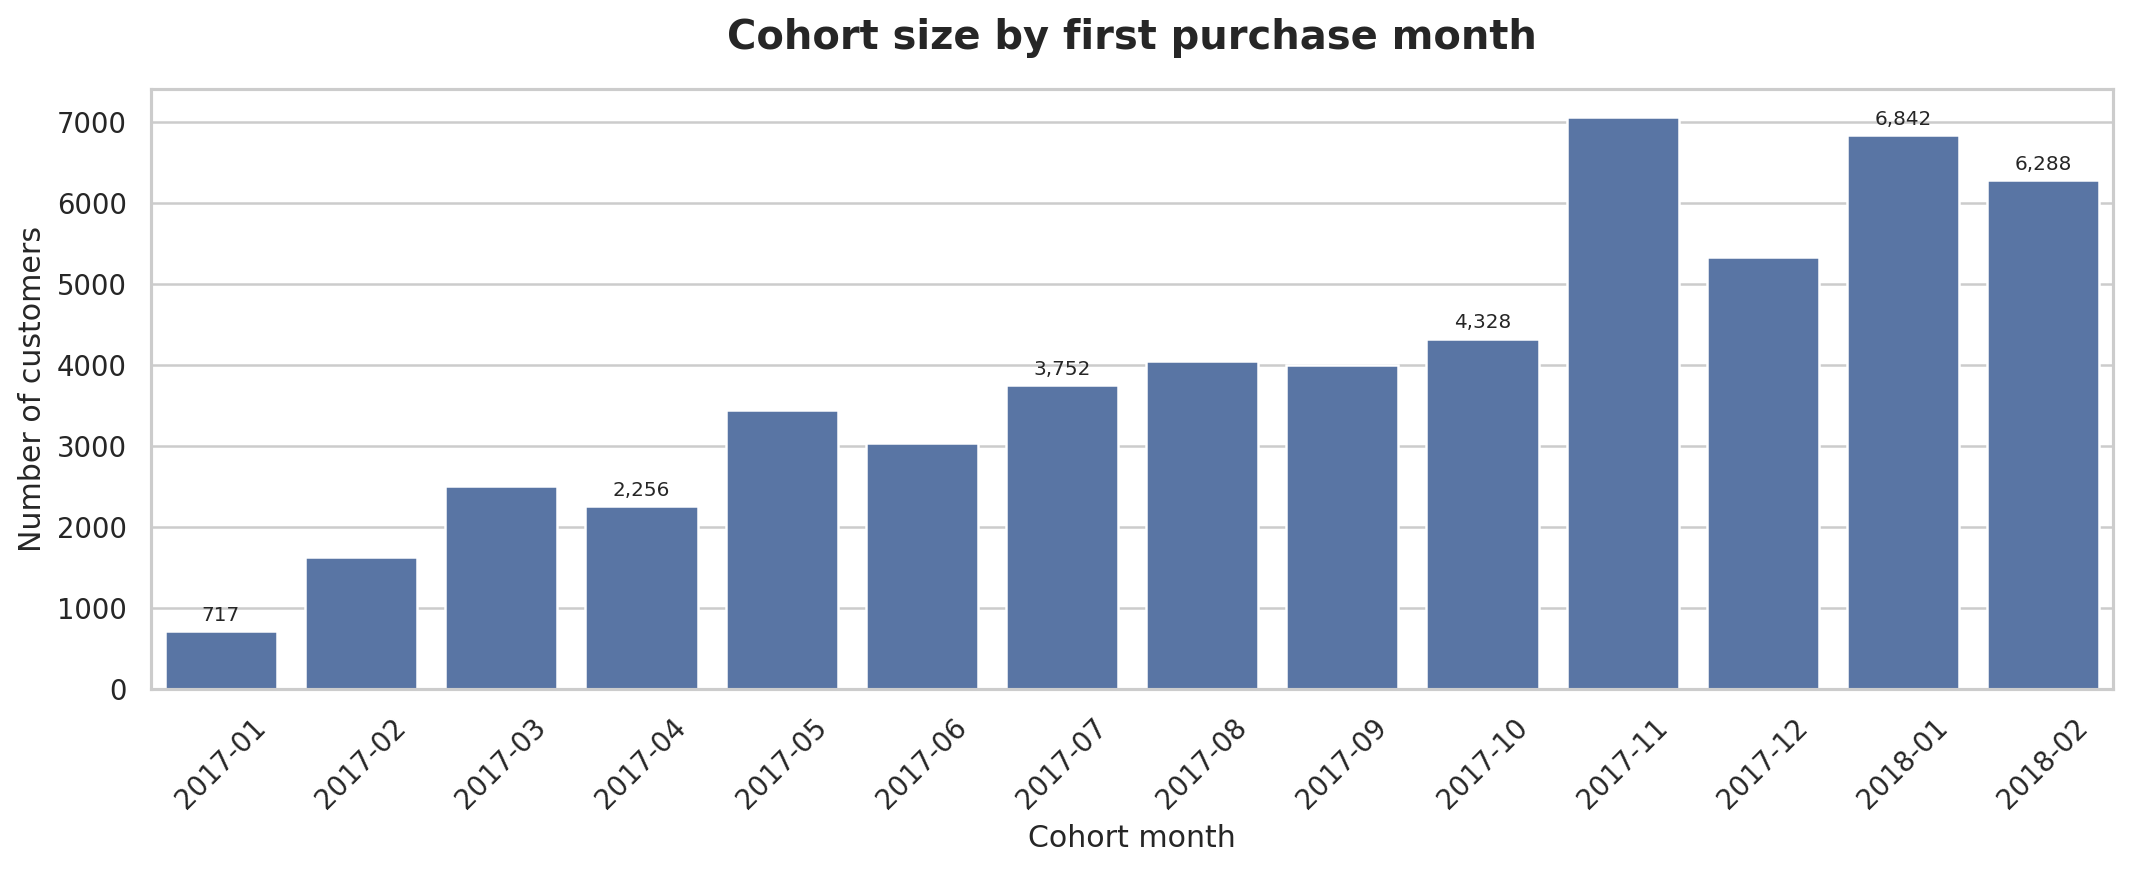

In [ ]:
#Cohort Size
cohort_size_output_path = "/content/drive/MyDrive/Data Project - Brazillian/cohort_size_portfolio.png"

cohort_size = (
    retention[retention["month_number"] == 0][["cohort_month", "active_users"]]
    .copy()
)

cohort_size["cohort_month"] = pd.to_datetime(cohort_size["cohort_month"])
cohort_size = cohort_size.sort_values("cohort_month")

cohort_size = cohort_size[
    (cohort_size["cohort_month"] >= pd.Timestamp("2017-01-01")) &
    (cohort_size["cohort_month"] <= pd.Timestamp("2018-02-01"))
].copy()

cohort_size["cohort_month_str"] = cohort_size["cohort_month"].dt.strftime("%Y-%m")

sns.set_theme(style="whitegrid", font_scale=1.0)

fig, ax = plt.subplots(figsize=(12, 5), dpi=180)

sns.barplot(
    data=cohort_size,
    x="cohort_month_str",
    y="active_users",
    ax=ax
)

ax.set_title("Cohort size by first purchase month", fontsize=16, fontweight="bold", pad=16)
ax.set_xlabel("Cohort month", fontsize=12)
ax.set_ylabel("Number of customers", fontsize=12)

plt.xticks(rotation=45)

for i, patch in enumerate(ax.patches):
    if i % 3 == 0 or i == len(ax.patches) - 1:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        ax.text(
            x,
            y + 80,
            f"{int(y):,}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.savefig(cohort_size_output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Customer acquisition increased significantly throughout 2017, suggesting rapid marketplace expansion during this period. However, strong acquisition growth alone does not guarantee sustainable revenue growth if retention remains low.

Key takeaway: The platform demonstrates strong customer acquisition but weak long-term engagement.

In [ ]:
# Merge retention rate

retention = retention.merge(cohort_size, on="cohort_month")
retention["retention_rate"] = retention["active_users"] / retention["cohort_size"]

In [ ]:
con.execute("""
  select * from retention limit 219
""").df()

,cohort_month,month_number,active_users,cohort_size,retention_rate
0,2016-09-01,0,1,1,1.000000
1,2016-10-01,0,262,262,1.000000
2,2016-10-01,6,1,262,0.003817
3,2016-10-01,9,1,262,0.003817
4,2016-10-01,11,1,262,0.003817
...,...,...,...,...,...
214,2018-06-01,1,25,5878,0.004253
215,2018-06-01,2,16,5878,0.002722
216,2018-07-01,0,5949,5949,1.000000
217,2018-07-01,1,31,5949,0.005211


In [ ]:
retention_pivot = retention.pivot(
    index="cohort_month",
    columns="month_number",
    values="retention_rate"
)

In [ ]:
retention_pivot

month_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.007634
2016-12-01,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,1.0,0.002789,0.002789,0.001395,0.004184,0.001395,0.004184,0.001395,0.001395,NaN,0.004184,0.001395,0.006974,0.004184,0.001395,0.001395,0.002789,0.004184,0.001395,NaN
2017-02-01,1.0,0.001843,0.003071,0.001229,0.004300,0.001229,0.002457,0.001843,0.001229,0.001843,0.001229,0.003071,0.001229,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN
2017-03-01,1.0,0.004395,0.003596,0.003995,0.003596,0.001598,0.001598,0.003196,0.003196,0.000799,0.003596,0.001199,0.001998,0.001199,0.001598,0.002397,0.000799,0.001199,NaN,NaN
2017-04-01,1.0,0.006206,0.002216,0.001773,0.002660,0.002660,0.003546,0.003103,0.003103,0.001773,0.002660,0.000887,0.000443,0.000443,0.000887,0.000887,0.001330,NaN,NaN,NaN
2017-05-01,1.0,0.004636,0.004636,0.002898,0.002898,0.003187,0.004057,0.001449,0.002608,0.002608,0.002608,0.003477,0.002318,0.000290,0.001739,0.002028,NaN,NaN,NaN,NaN
2017-06-01,1.0,0.004939,0.003951,0.004281,0.002963,0.003951,0.003622,0.002305,0.001317,0.001976,0.002963,0.003622,0.001646,0.001646,0.002305,NaN,NaN,NaN,NaN,NaN


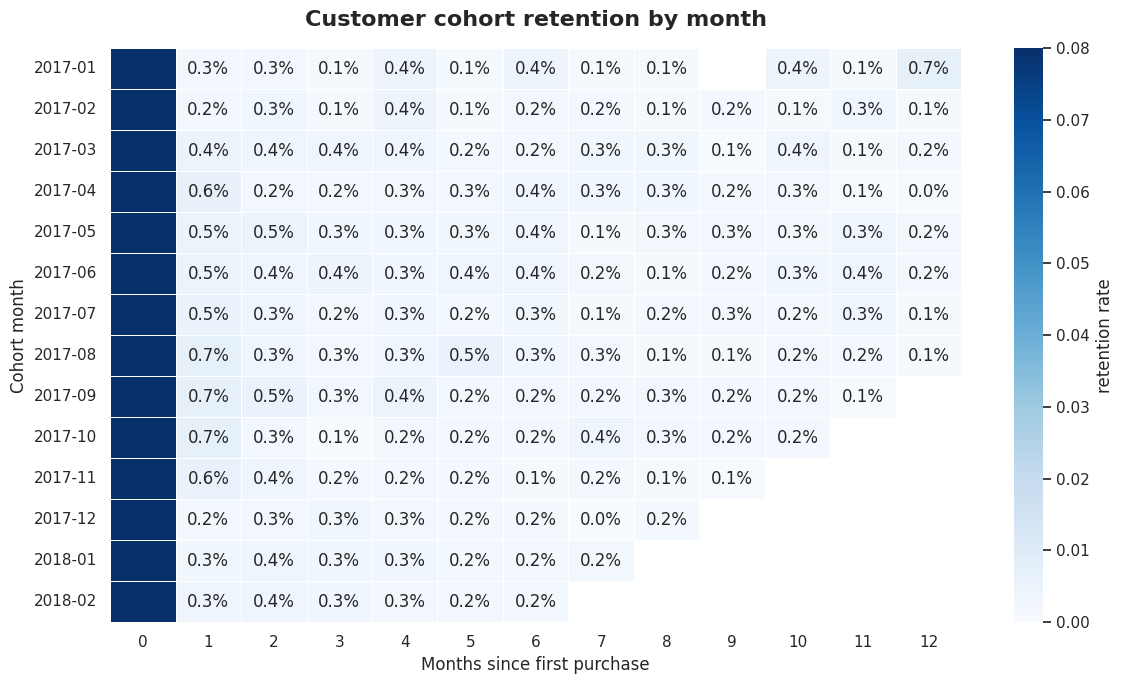

In [ ]:
# Retenion Heatmap
heatmap_output_path = "/content/drive/MyDrive/Data Project - Brazillian/retention_heatmap_portfolio.png"

max_month = 12
retention_plot = retention[retention["month_number"] <= max_month].copy()

retention_plot["cohort_month_str"] = pd.to_datetime(
    retention_plot["cohort_month"]
).dt.strftime("%Y-%m")
retention_plot = retention_plot[
    (retention_plot["cohort_month"] >= pd.Timestamp("2017-01-01")) &
    (retention_plot["cohort_month"] <= pd.Timestamp("2018-02-01"))
].copy()
retention_pivot = retention_plot.pivot(
    index="cohort_month_str",
    columns="month_number",
    values="retention_rate"
)

annot_data = retention_pivot.copy()

for col in annot_data.columns:
    if col == 0:
        annot_data[col] = ""
    else:
        annot_data[col] = annot_data[col].apply(
            lambda x: f"{x:.1%}" if pd.notnull(x) else ""
        )

mask = retention_pivot.isnull()

sns.set_theme(style="white", font_scale=1.0)

plt.figure(figsize=(12, 7))

ax = sns.heatmap(
    retention_pivot,
    mask=mask,
    annot=annot_data,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "retention rate"},
    vmin=0,
    vmax=0.08
)

plt.title("Customer cohort retention by month", fontsize=16, weight="bold", pad=16)
plt.xlabel("Months since first purchase", fontsize=12)
plt.ylabel("Cohort month", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(heatmap_output_path, bbox_inches="tight", facecolor="white")
plt.show()





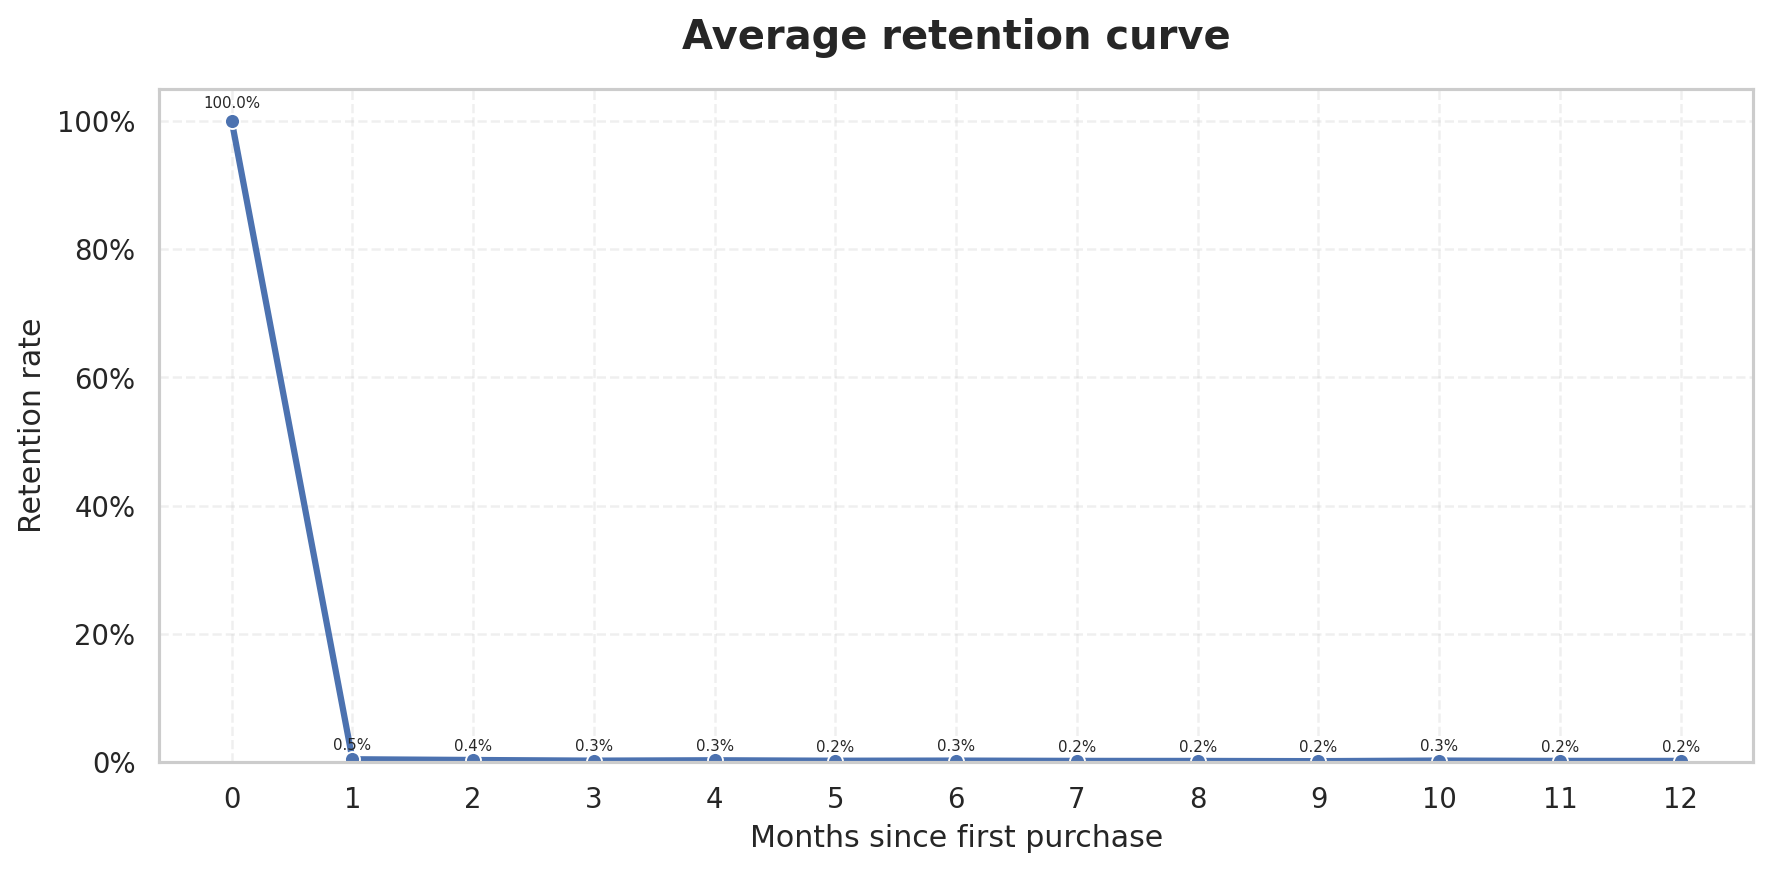

In [ ]:
# Retention Curve
curve_output_path = "/content/drive/MyDrive/Data Project - Brazillian/retention_curve_portfolio.png"

retention_curve = retention.copy()
retention_curve["cohort_month"] = pd.to_datetime(retention_curve["cohort_month"])

retention_curve = retention_curve[
    (retention_curve["month_number"] <= 12) &
    (retention_curve["cohort_month"] >= pd.Timestamp("2017-01-01")) &
    (retention_curve["cohort_month"] <= pd.Timestamp("2018-02-01"))
].copy()

retention_curve = (
    retention_curve
    .groupby("month_number", as_index=False)["retention_rate"]
    .mean()
)

sns.set_theme(style="whitegrid", font_scale=1.0)

fig, ax = plt.subplots(figsize=(10, 5), dpi=180)

sns.lineplot(
    data=retention_curve,
    x="month_number",
    y="retention_rate",
    marker="o",
    linewidth=2.5,
    ax=ax
)

ax.set_title("Average retention curve", fontsize=16, fontweight="bold", pad=16)
ax.set_xlabel("Months since first purchase", fontsize=12)
ax.set_ylabel("Retention rate", fontsize=12)

ax.set_xticks(range(0, 13))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1.05)

ax.grid(True, linestyle="--", alpha=0.3)

for x, y in zip(retention_curve["month_number"], retention_curve["retention_rate"]):
    ax.text(
        x,
        y + 0.015 if x == 0 else y + 0.01,   # month 0 cao hơn chút để dễ nhìn
        f"{y:.1%}",
        ha="center",
        va="bottom",
        fontsize=6
    )

plt.tight_layout()
plt.savefig(curve_output_path, bbox_inches="tight", facecolor="white")
plt.show()


Month 0 retention is 100% by definition, while repeat purchase drops sharply from Month 1 onward.

Most cohorts show very low retention after the first purchase (between 0.5-Repeat Purchase Distributionz0.6%), suggesting that Olist behaves more like a one-time purchase marketplace than a habit-driven ecommerce platform. -->

Retention stabilizes at a low level after the early drop, which indicates that the biggest opportunity lies in improving the first repeat purchase.


Key takeaway: The marketplace currently behaves more like a transactional platform rather than a recurring shopping destination.

In [ ]:
# Repeat Purchase Distribution
orders_per_customer = con.execute("""
  select
      customer_unique_id,
      count(*) as order_count
  from orders_clean
  group by customer_unique_id
""").df()

# distribution by order count
dist = (
    orders_per_customer
    .groupby("order_count")
    .size()
    .reset_index(name="customers")
)

dist["share"] = dist["customers"] / dist["customers"].sum()
dist

,order_count,customers,share
0,1,87894,0.941473
1,2,4581,0.049069
2,3,524,0.005613
3,4,156,0.001671
4,5,70,0.000750
5,6,49,0.000525
6,7,30,0.000321
7,8,12,0.000129
8,9,9,0.000096
9,10,4,0.000043


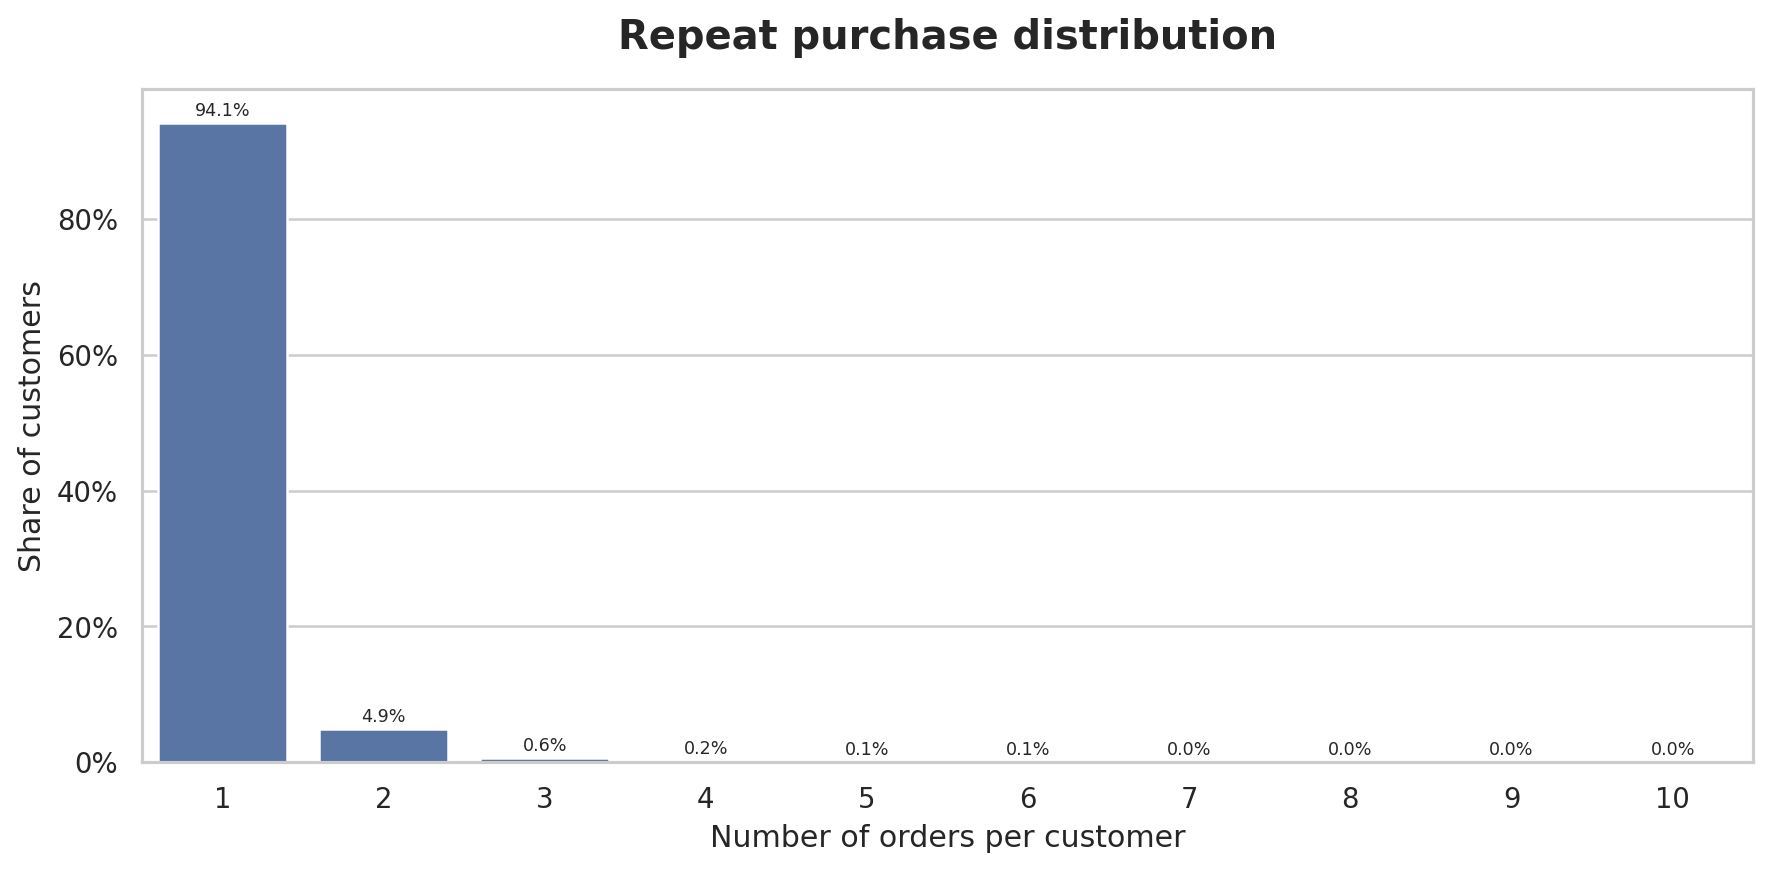

In [ ]:
# Repeat Purchase Distribution
repeat_purchase_output_path = "/content/drive/MyDrive/Data Project - Brazillian/repeat_purchase_distribution_portfolio.png"

dist["share"] = dist["customers"] / dist["customers"].sum()

dist_plot = dist[dist["order_count"] <= 10].copy()
sns.set_theme(style="whitegrid", font_scale=1.0)

fig, ax = plt.subplots(figsize=(10, 5), dpi=180)

sns.barplot(
    data=dist_plot,
    x="order_count",
    y="share",
    ax=ax
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for _, row in dist_plot.iterrows():
    ax.text(
        row["order_count"] - 1,
        row["share"] + 0.005,
        f"{row['share']:.1%}",
        ha="center",
        va="bottom",
        fontsize=7
    )

ax.set_title("Repeat purchase distribution", fontsize=16, fontweight="bold", pad=16)
ax.set_xlabel("Number of orders per customer", fontsize=12)
ax.set_ylabel("Share of customers", fontsize=12)

ax.set_ylim(0, dist_plot["share"].max() + 0.05)

plt.tight_layout()
plt.savefig(repeat_purchase_output_path, bbox_inches="tight", facecolor="white"
)
plt.show()

Nealy 95% of customers made only a single purchase, which explains the sharp retention drop observed in the cohort analysis.

The platform captures only a small portion of potential lifetime value because very few customers progress to repeat purchasing behavior. This suggests that Olist operates more like a one-time purchase marketplace than a habit-driven ecommerce platform.

In [ ]:
# LTV Analysis

revenue_per_customer = con.execute("""
select
customer_unique_id,
sum(revenue) as total_revenue,
count(*) as order_count
from orders_clean
group by customer_unique_id
""").df()



Customers who return tend to make their second purchase relatively quickly.

Half of repeat purchases happen within 28 days

Many repeat purchases occur within 1–3 months


There appears to be a short window of opportunity after the first purchase where customers are most likely to buy again.

If customers do not return within this early period, the probability of a second purchase drops significantly.

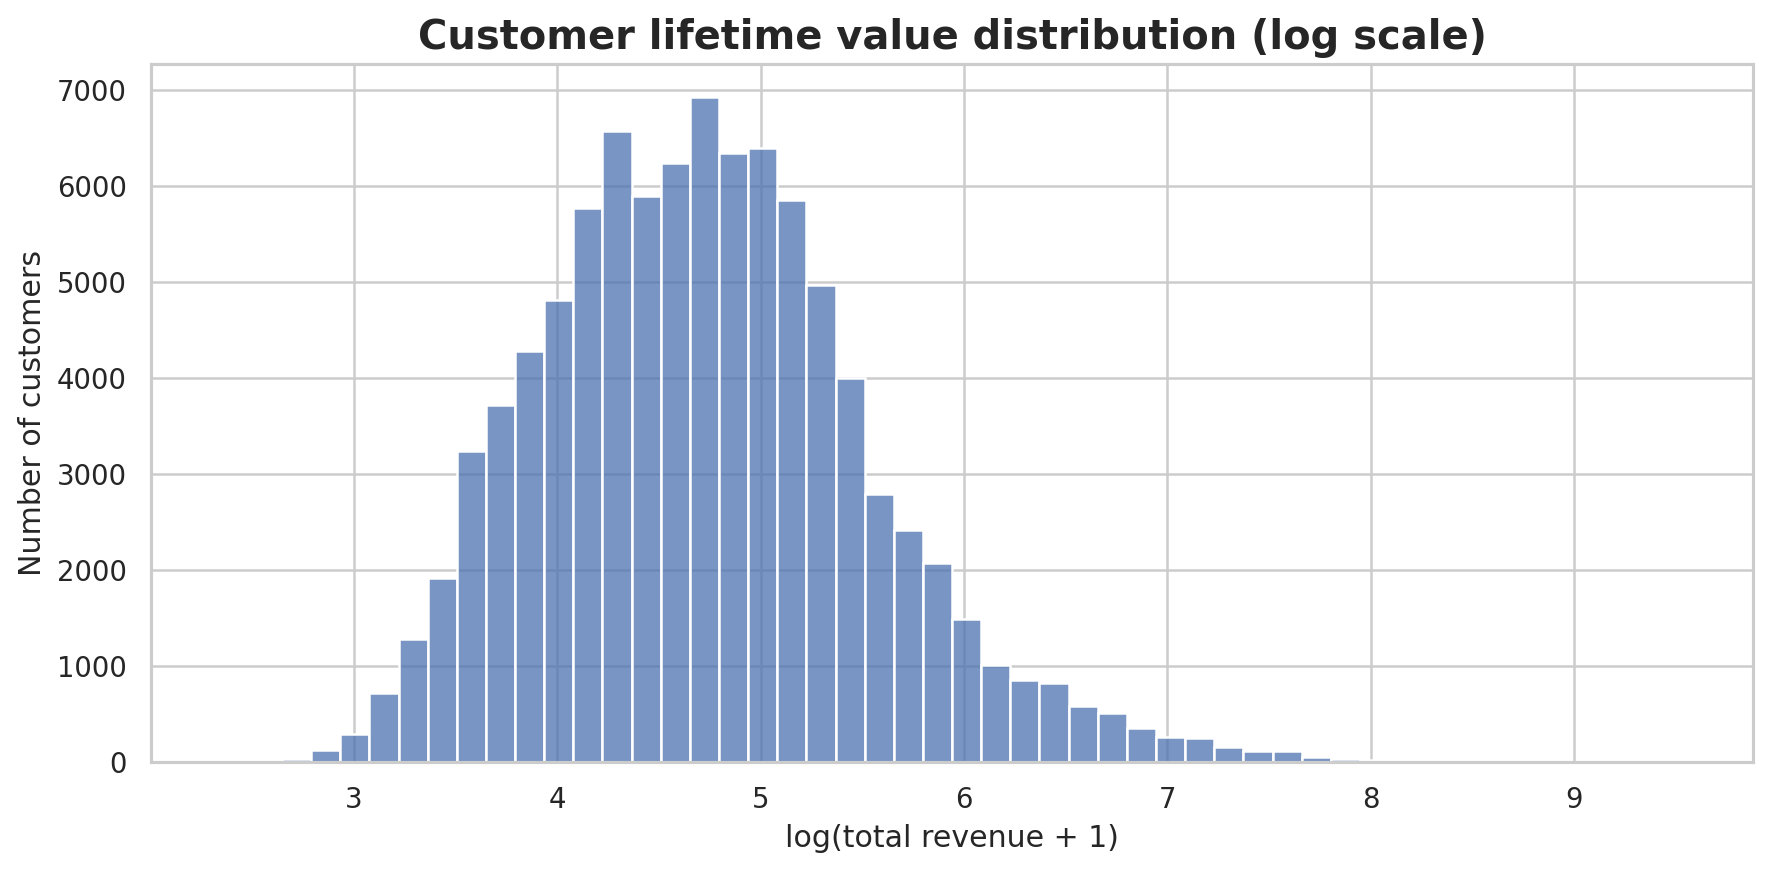

In [ ]:
# LTV
sns.set_theme(style="whitegrid")

ltv_distribution_log = "/content/drive/MyDrive/Data Project - Brazillian/ltv_distribution_log.png"

fig, ax = plt.subplots(figsize=(10,5), dpi=180)

sns.histplot(
    np.log1p(revenue_per_customer["total_revenue"]),
    bins=50,
    ax=ax
)

ax.set_title("Customer lifetime value distribution (log scale)", fontsize=16, fontweight="bold")
ax.set_xlabel("log(total revenue + 1)")
ax.set_ylabel("Number of customers")

plt.tight_layout()

plt.savefig(ltv_distribution_log, dpi=300, bbox_inches="tight")

plt.show()

Customer lifetime value follows a strongly right-skewed distribution, where a small number of customers generate disproportionately high revenue.

Key takeaway: Increasing the number of repeat customers could significantly shift the revenue distribution.

In [ ]:
revenue_per_customer.groupby("order_count")["total_revenue"].median()

,total_revenue
order_count,
1,105.650
2,160.960
3,167.100
4,114.250
5,125.765
6,106.380
7,147.360
8,149.670
9,189.080


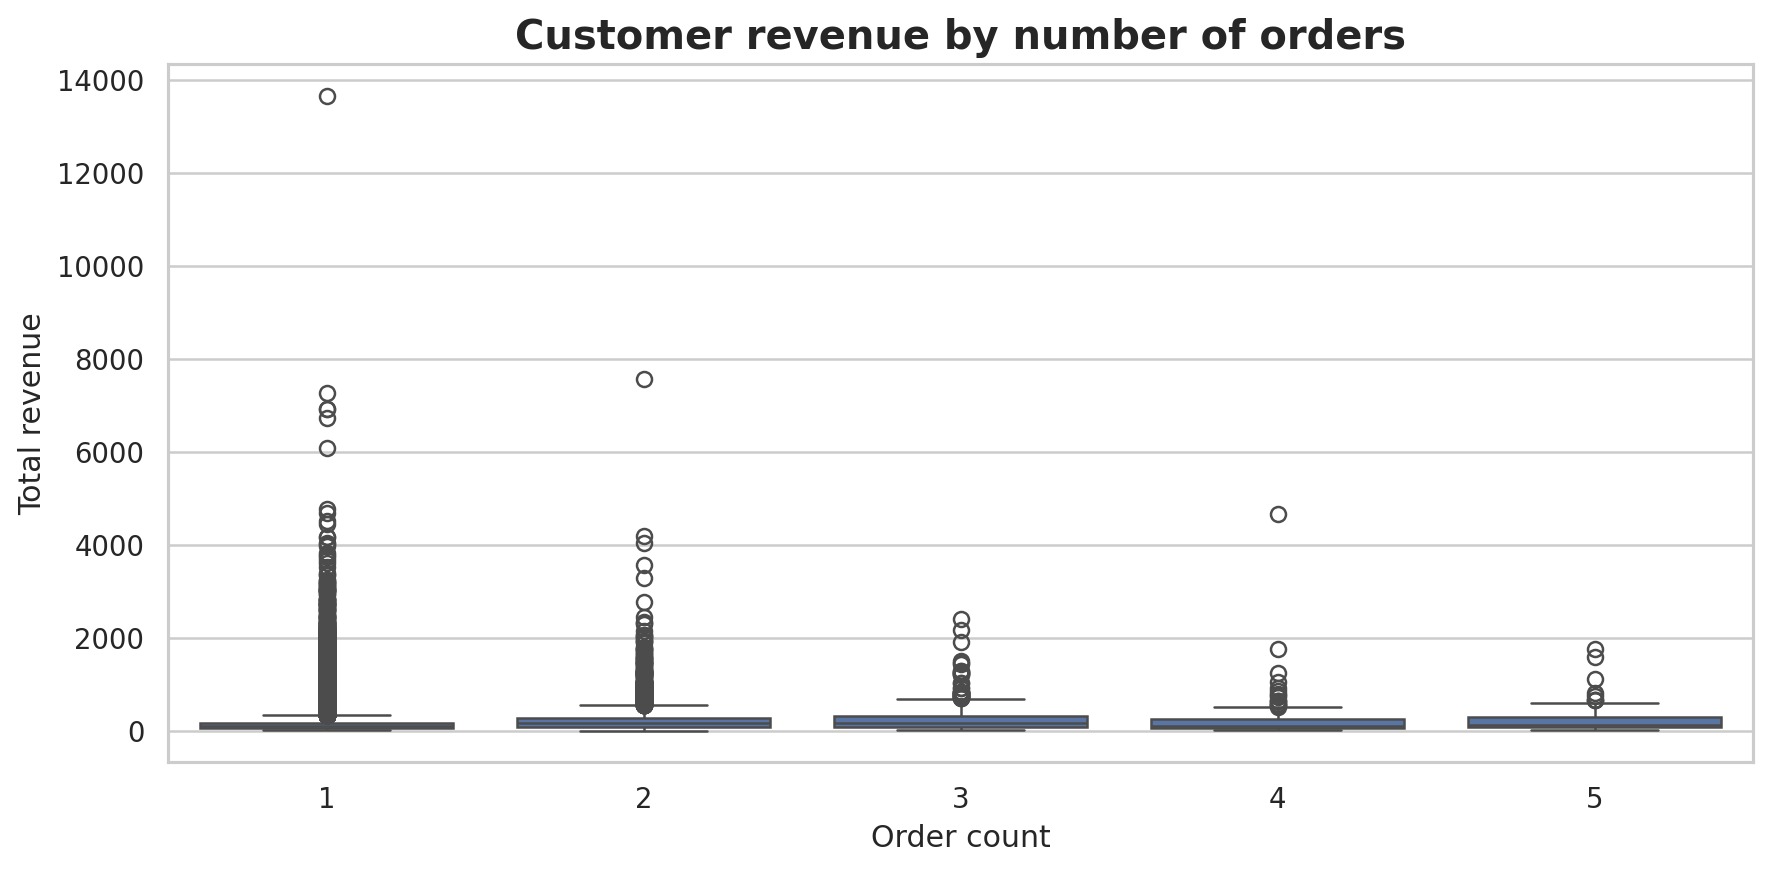

In [ ]:
# Revenue by order of customer
fig, ax = plt.subplots(figsize=(10,5), dpi=180)
revenue_by_order_count = "/content/drive/MyDrive/Data Project - Brazillian/revenue_by_order_count.png"

sns.boxplot(
    data=revenue_per_customer[revenue_per_customer["order_count"] <= 5],
    x="order_count",
    y="total_revenue"
)

ax.set_title("Customer revenue by number of orders", fontsize=16, fontweight="bold")
ax.set_xlabel("Order count")
ax.set_ylabel("Total revenue")

plt.tight_layout()

plt.savefig(revenue_by_order_count, dpi=300)
plt.savefig(revenue_by_order_count, dpi=300, bbox_inches="tight")

plt.show()

Converting a customer from 1 purchase → 2 purchases dramatically increases lifetime value.

However, since only ~6% of customers reach this stage, the platform currently fails to capitalize on this potential value.

In [ ]:
customer_segment = revenue_per_customer.copy()

customer_segment["segment"] = np.where(
    customer_segment["order_count"] == 1,
    "one_time",
    "repeat"
)

customer_segment["segment"].value_counts(normalize=True)

,proportion
segment,
one_time,0.941473
repeat,0.058527


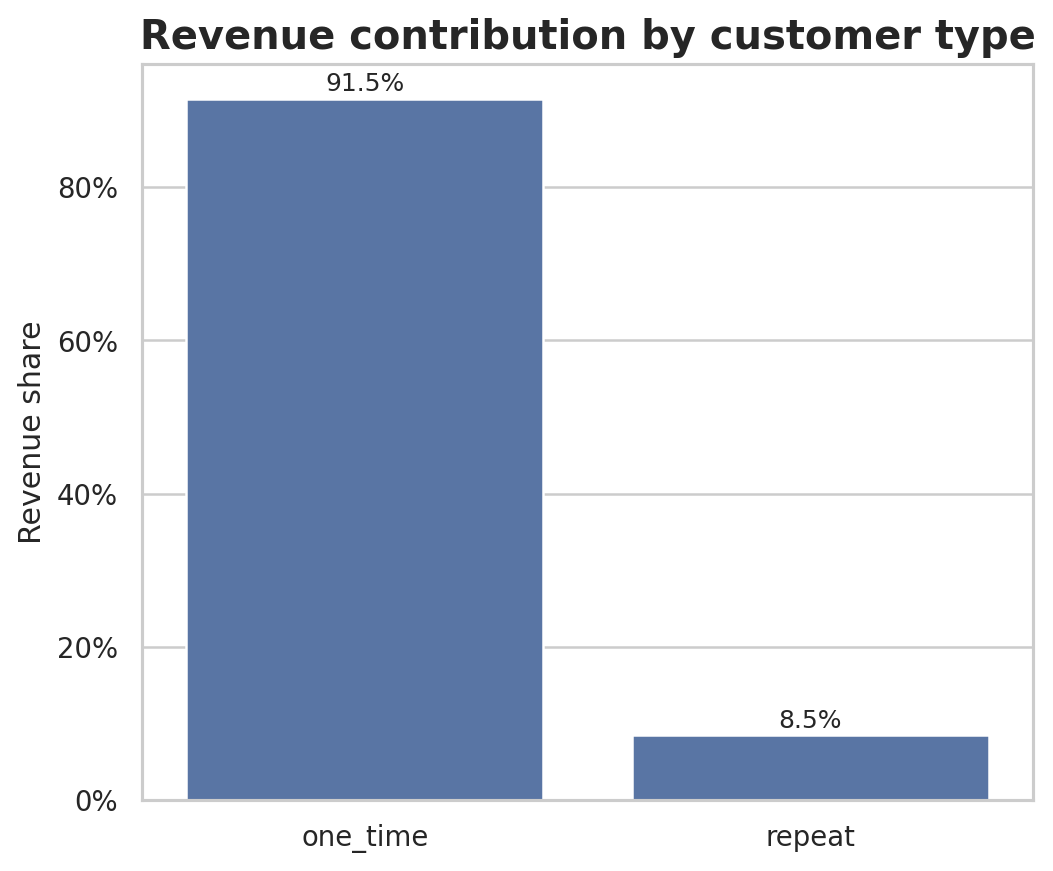

In [ ]:
# Revenue Contribution: Repeat vs One-Time Customers
customer_segment = revenue_per_customer.copy()

customer_segment["segment"] = np.where(
    customer_segment["order_count"] == 1,
    "one_time",
    "repeat"
)

segment_revenue = (
    customer_segment
    .groupby("segment", as_index=False)["total_revenue"]
    .sum()
)

segment_revenue["share"] = (
    segment_revenue["total_revenue"]
    / segment_revenue["total_revenue"].sum()
)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(6,5), dpi=180)

sns.barplot(
    data=segment_revenue,
    x="segment",
    y="share",
    ax=ax
)

ax.set_title("Revenue contribution by customer type", fontsize=16, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Revenue share")

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

for i, v in enumerate(segment_revenue["share"]):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/Data Project - Brazillian/revenue_share_segment.png",
            dpi=300, bbox_inches="tight")

plt.show()

Customers who make multiple purchases generate substantially higher lifetime revenue. For example, customers who make two purchases generate approximately 1.5X higher median revenue than one-time buyers.

Key takeaway: Encouraging a second purchase represents one of the most impactful levers for increasing customer lifetime value.

6. Revenue Contrib

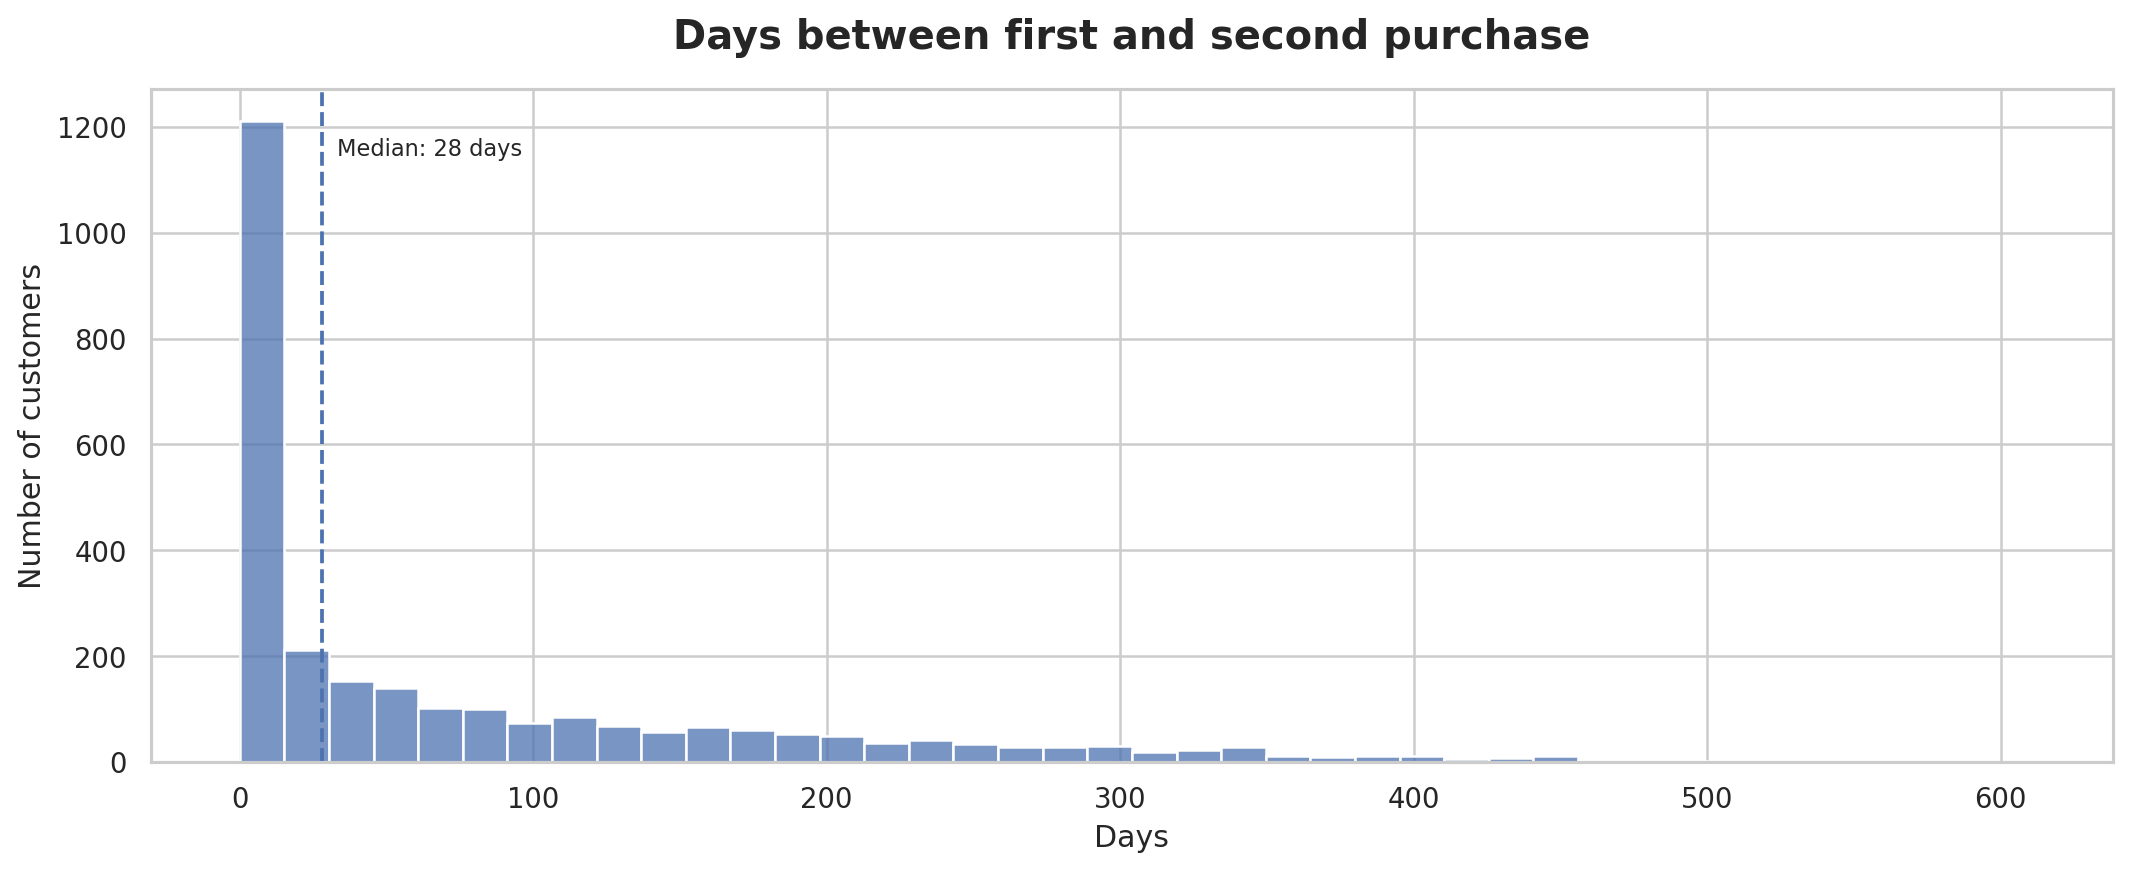

In [ ]:
# #Days between 1st and 2nd purchase
second_purchase_gap_output_path = "/content/drive/MyDrive/Data Project - Brazillian/time_to_second_purchase_portfolio.png"

orders_raw = con.execute("""
select
    c.customer_unique_id,
    cast(o.order_purchase_timestamp as timestamp) as purchase_ts
from read_csv_auto('/content/drive/MyDrive/Data Project - Brazillian/olist_orders_dataset.csv') o
left join read_csv_auto('/content/drive/MyDrive/Data Project - Brazillian/olist_customers_dataset.csv') c
    on o.customer_id = c.customer_id
where o.order_status = 'delivered'
""").df()

orders_raw = orders_raw.sort_values(["customer_unique_id", "purchase_ts"]).copy()

orders_raw["purchase_rank"] = orders_raw.groupby("customer_unique_id").cumcount() + 1

first_purchase = orders_raw[orders_raw["purchase_rank"] == 1][
    ["customer_unique_id", "purchase_ts"]
].rename(columns={"purchase_ts": "first_purchase_ts"})

second_purchase = orders_raw[orders_raw["purchase_rank"] == 2][
    ["customer_unique_id", "purchase_ts"]
].rename(columns={"purchase_ts": "second_purchase_ts"})

repeat_gap = first_purchase.merge(
    second_purchase,
    on="customer_unique_id",
    how="inner"
)

repeat_gap["days_between"] = (
    repeat_gap["second_purchase_ts"] - repeat_gap["first_purchase_ts"]
).dt.days

repeat_gap = repeat_gap[repeat_gap["days_between"].notnull()].copy()
repeat_gap = repeat_gap[repeat_gap["days_between"] >= 0].copy()

sns.set_theme(style="whitegrid", font_scale=1.0)

fig, ax = plt.subplots(figsize=(12, 5), dpi=180)

sns.histplot(
    repeat_gap["days_between"],
    bins=40,
    ax=ax
)

ax.set_title("Days between first and second purchase", fontsize=16, fontweight="bold", pad=16)
ax.set_xlabel("Days", fontsize=12)
ax.set_ylabel("Number of customers", fontsize=12)

median_days = repeat_gap["days_between"].median()
ax.axvline(median_days, linestyle="--", linewidth=1.5)
ax.text(
    median_days + 5,
    ax.get_ylim()[1] * 0.9,
    f"Median: {median_days:.0f} days",
    fontsize=9
)

plt.tight_layout()
plt.savefig(second_purchase_gap_output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

The median time to second purchase is 28 days, indicating a short window where customers are most likely to return.

Key takeaway: Retention strategies should focus on the first 30 days after the initial purchase.

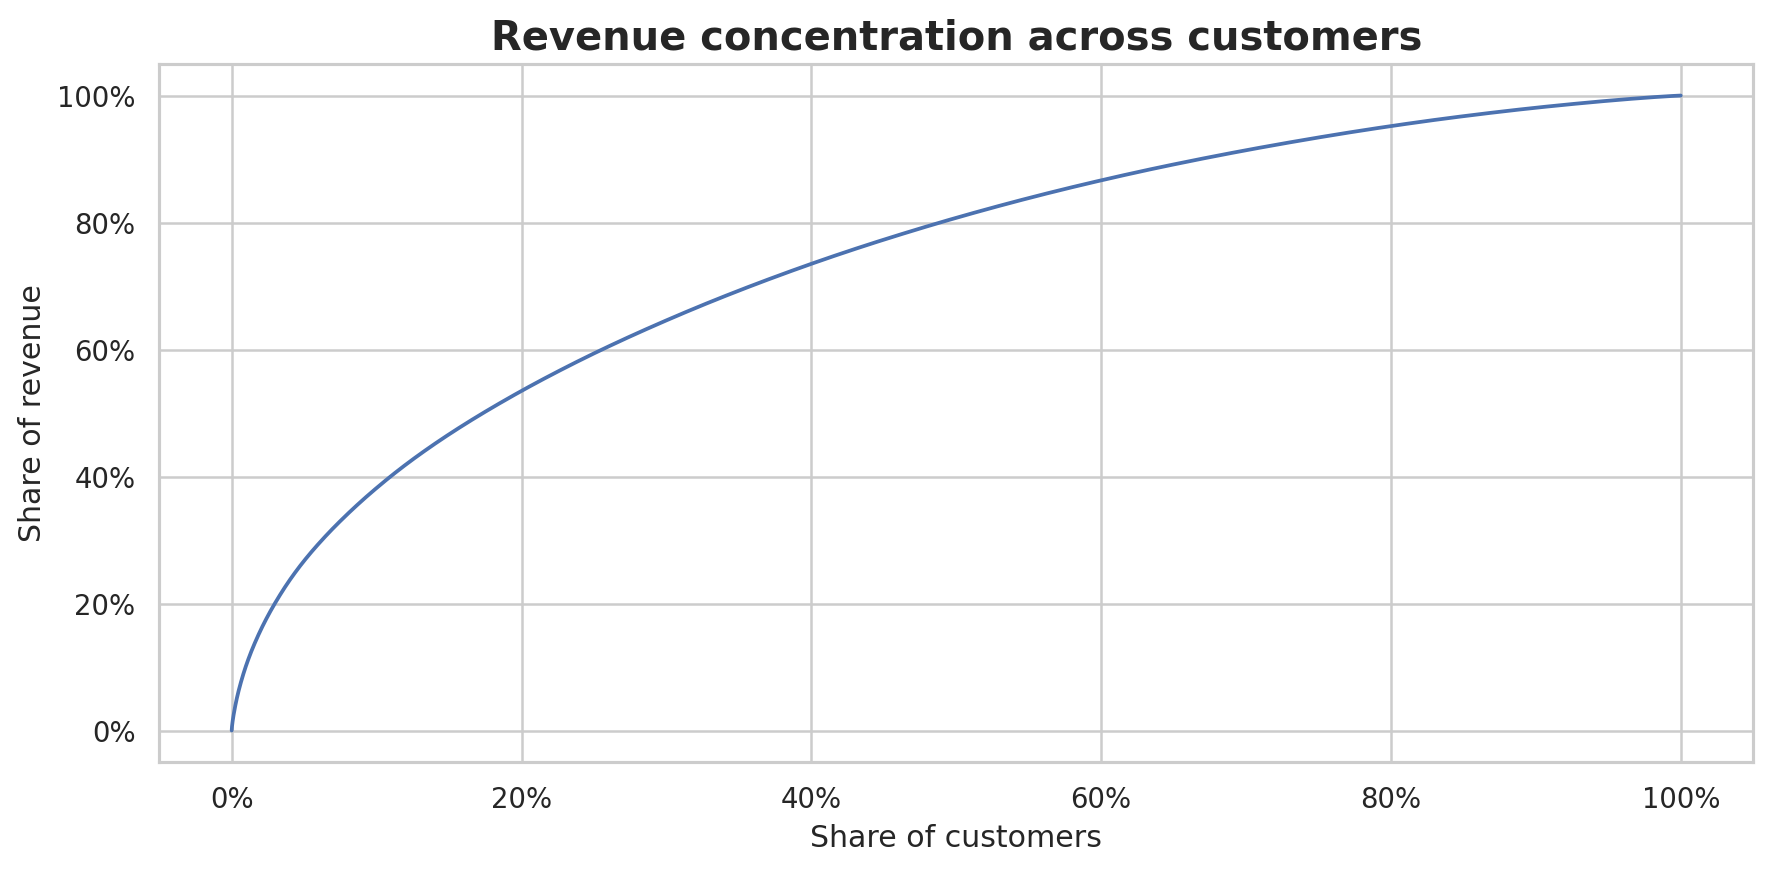

In [ ]:
# Revenue concentration
pareto_revenue_concentration  = "/content/drive/MyDrive/Data Project - Brazillian/pareto_revenue_concentration.png"

ltv = revenue_per_customer.sort_values("total_revenue", ascending=False)

ltv["cum_revenue"] = ltv["total_revenue"].cumsum()
ltv["cum_revenue_pct"] = ltv["cum_revenue"] / ltv["total_revenue"].sum()
ltv["customer_pct"] = np.arange(1, len(ltv)+1) / len(ltv)

fig, ax = plt.subplots(figsize=(10,5), dpi=180)

sns.lineplot(
    x=ltv["customer_pct"],
    y=ltv["cum_revenue_pct"]
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))

ax.set_title("Revenue concentration across customers", fontsize=16, fontweight="bold")
ax.set_xlabel("Share of customers")
ax.set_ylabel("Share of revenue")

plt.tight_layout()

plt.savefig("pareto_revenue.png", dpi=300)
plt.savefig(pareto_revenue_concentration, dpi=300, bbox_inches="tight")
plt.show()

Revenue follows a Pareto-like distribution, where a relatively small share of customers generates a large share of revenue.

Key takeaway: Targeted retention strategies focused on high-value customers could significantly increase revenue efficiency.

# Why Retention Appears Extremely Low
The extremely low retention rate observed in the dataset can be explained by several structural factors.

First, the dataset represents transactions from a marketplace environment where purchases are typically need-based rather than habit-based. Customers often buy a product to solve a specific need and may not return frequently.

Second, customers in the dataset interact primarily with large marketplaces such as Mercado Livre or Magazine Luiza rather than directly with Olist itself. As a result, customer loyalty is directed toward the marketplace rather than the underlying seller infrastructure.

Third, many products in the dataset belong to categories such as electronics, furniture, and home appliances, which naturally have low purchase frequency and long replacement cycles.

Finally, the dataset covers a limited time window, which may underestimate repeat purchase behavior for customers whose next purchase occurs outside the observation period.
Revenue is strongly concentrated among a relatively small share of customers.

A minority of high-value customers contributes a disproportionate portion of total revenue, indicating that repeat customers play a crucial role in overall business performance.

# Key Insight

A very small portion of repeat customers drives a disproportionate share of revenue, suggesting that improving customer retention and encouraging second purchases could significantly increase long-term revenue.

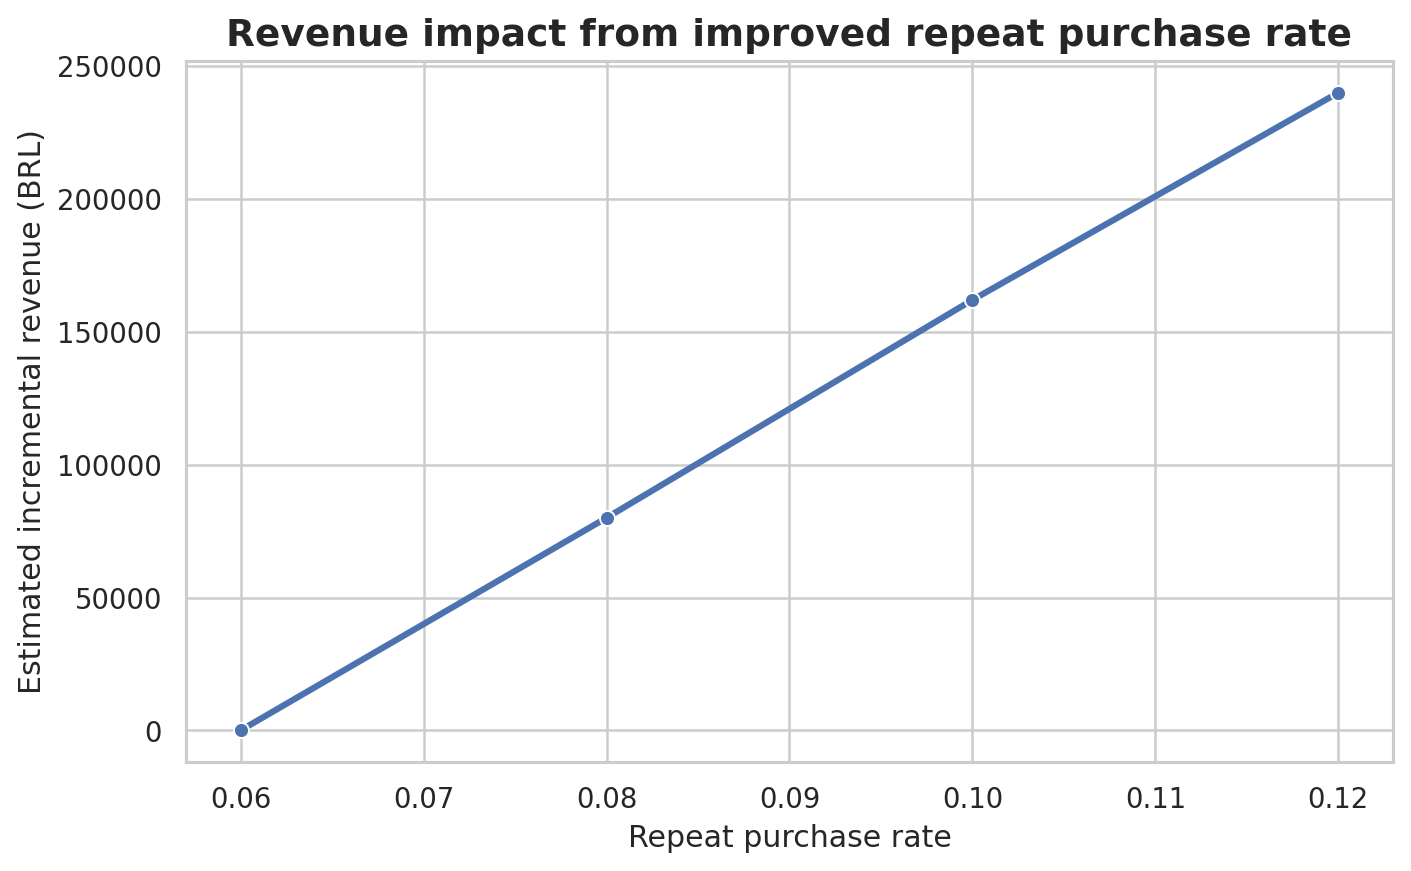

In [8]:
simulation = pd.DataFrame({
    "repeat_rate":[0.06,0.08,0.10,0.12],
    "expected_revenue":[0,80000,162000,240000]
})

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8,5), dpi=180)

sns.lineplot(
    data=simulation,
    x="repeat_rate",
    y="expected_revenue",
    marker="o",
    linewidth=2.5,
    ax=ax
)

ax.set_title("Revenue impact from improved repeat purchase rate", fontsize=15, weight="bold")
ax.set_xlabel("Repeat purchase rate")
ax.set_ylabel("Estimated incremental revenue (BRL)")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Data Project - Brazillian/retention_revenue_simulation.png", dpi=300, bbox_inches="tight")
plt.show()